
# Week 2 — Data Representation in Tensors
**Course:** SCH-MGMT 661 — Applications of AI Models  
**Topic:** Scalars → Vectors → Matrices → Time Series → Images → Slicing → Practice  
**Source:** *Deep Learning with Python (3rd ed.)*, Chapter **2.2**  




## Learning Objectives
- Define **tensor**, **rank (ndim)**, **shape**, and **dtype**.  
- Recognize common ranks in practice: **tabular (rank-2)**, **time series (rank-3)**, **images (rank-4)**.  
- Perform **tensor slicing** to select samples, ranges, and channels.  
- Run short **practice** tasks to cement concepts.



## 1. What is a Tensor?
A **tensor** is a container for numbers with one or more axes.  
- **Rank (ndim):** number of axes.  
- **Shape:** how many elements are along each axis.  
- **dtype:** numeric type of elements (e.g., `uint8`, `float32`).

> We will mirror the compact examples from DLWP Ch. 2.2.



## 2. Scalars (Rank-0), Vectors (Rank-1), Matrices (Rank-2), and Rank-3 Tensors (Book Chapter 2.2.1–2.2.4)
Below, each example let's print the **rank** and **shape** of tensors


In [13]:

import numpy as np

# Scalar (rank-0)
x = np.array(12)
print("Scalar:", x, "| ndim:", x.ndim, "| shape:", x.shape)




Scalar: 12 | ndim: 0 | shape: ()


In [14]:
# Vector (rank-1)
x = np.array([12, 3, 6, 14, 7])
print("Vector:", x, "| ndim:", x.ndim, "| shape:", x.shape)



Vector: [12  3  6 14  7] | ndim: 1 | shape: (5,)


In [15]:
# Matrix (rank-2)
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])

print("Matrix:", x, "ndim:", x.ndim, "| shape:", x.shape)

Matrix: [[ 5 78  2 34  0]
 [ 6 79  3 35  1]
 [ 7 80  4 36  2]] ndim: 2 | shape: (3, 5)


In [16]:
# Rank-3 tensor

x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
print("Rank-3:", x, "ndim:", x.ndim, "| shape:", x.shape)

Rank-3: [[[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]

 [[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]

 [[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]] ndim: 3 | shape: (3, 3, 5)



## 3. Rank-2 (Tabular) — Airbnb Listing Features
Each row is a **listing**; each column is a **feature** (static attributes).
- Example features: **bedrooms**, **bathrooms**, **number_of_reviews**  
- Shape: `(samples, features)`


In [17]:

# 4 listings × 3 features [bedrooms, bathrooms, reviews]
airbnb_features = np.array([
    [2, 1, 57],
    [1, 1, 13],
    [3, 2, 201],
    [2, 1, 88],
], dtype=np.float32)

print("Rank-2 Airbnb -> ndim:", airbnb_features.ndim, "| shape:", airbnb_features.shape)


Rank-2 Airbnb -> ndim: 2 | shape: (4, 3)



## 4. Rank-3 (Time Series) — Stock Prices
We represent one trading year of intraday data as:
- **Shape:** `(250, 390, 3)`  
- **Meaning:** `250 days × 390 minutes × [open, high, low]`


In [18]:

# Stock Prices: 250 days × 390 minutes × 3 features [open, high, low]
stock_prices = np.random.rand(250, 390, 3).astype(np.float32) * 100
print("Rank-3 Stocks -> ndim:", stock_prices.ndim, "| shape:", stock_prices.shape)


Rank-3 Stocks -> ndim: 3 | shape: (250, 390, 3)



### Slicing Time Series (Book Chapters 2.2.6)
Common selections you’ll use later for modeling:
- **Last 5 days (most recent 5 days)**: `stock_prices[-5:] → (5, 390, 3)`  

*   List item
*   List item


- **Only Opening price feature**: `stock_prices[:, :, 0] → (250, 390)`  
- **Minute window (e.g., 60..119)**: `stock_prices[:, 60:120, :] → (250, 60, 3)`


In [19]:

# Last 5 days, all minutes/features
last5 = stock_prices[-5:]
print("last5:", last5.shape)


last5: (5, 390, 3)


In [20]:
# Only opening price feature across all days/minutes
open_only = stock_prices[:, :, 0]
print("open_only:", open_only.shape)

open_only: (250, 390)


In [21]:
# Minute window 60..119
window = stock_prices[:, 60:120, :]
print("window:", window.shape)

window: (250, 60, 3)



## 5. Rank-4 (Images) — MNIST Digits Dataset
`train_images` loads as `(60000, 28, 28)` (**rank-3**).  
We add a channel axis to make it **rank-4**: `(60000, 28, 28, 1)`.


In [22]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
# Now let's checck the rank, data type, and the shpape of train images dataset

print("| ndim:", train_images.ndim, "| shape:", train_images.shape, "|dtype", train_images.dtype)

| ndim: 3 | shape: (60000, 28, 28) |dtype uint8


In [24]:
# We add a channel axis to make it rank-4: (60000, 28, 28, 1).
train4 = train_images.reshape((60000, 28, 28, 1))
print("| ndim:", train4.ndim, "| shape:", train4.shape, "|dtype", train_images.dtype)

| ndim: 4 | shape: (60000, 28, 28, 1) |dtype uint8



## 6.Slicing Images  (Book Chapters 2.2.6)
- Samples 10 to 99: `train_images[10:100] → (90, 28, 28)`  

Equvalent to:
- `train_images[10:100, :, :]`  
- `train_images[10:100, 0:28, 0:28]`  



In [25]:
# Image samples

slice1 = train_images[9:100]
slice2 = train_images[9:100, :, :]
slice3 = train_images[9:100, 0:28, 0:28]

print("slice1:", slice1.shape, "| slice2:", slice2.shape, "| slice3:", slice3.shape)



slice1: (90, 28, 28) | slice2: (90, 28, 28) | slice3: (90, 28, 28)


We can use slicing to extract a center patch from MNIST digits.
Each MNIST image is 28×28, so cropping 7:-7 on both axes gives a 14×14 center.

In [26]:
# Slice out center 14×14 patches from all training images

center_slices = train_images[:, 7:-7, 7:-7]

print("Original shape:", train_images.shape)
print("Center patch shape:", center_slices.shape)


Original shape: (60000, 28, 28)
Center patch shape: (60000, 14, 14)


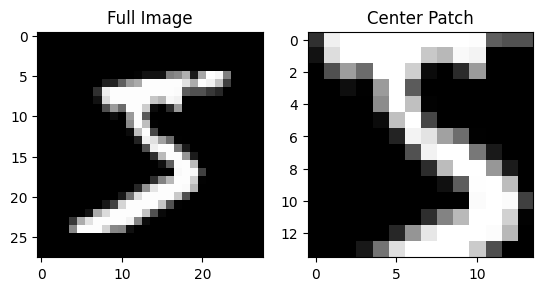

In [27]:
# Let's visualize the original and center patch side-by-side

import matplotlib.pyplot as plt

# Pick an image

full_img = train_images[0]
patch_img = center_slices[0]

# diplay

plt.subplot(1, 2, 1)
plt.title("Full Image")
plt.imshow(full_img, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Center Patch")
plt.imshow(patch_img, cmap="gray")

plt.show()



## 6. Practice: Image Slicing with MNIST


## Define corner slices
We can slice different corners of an MNIST digit by choosing a value x.

:-x → take everything except the last x rows/columns (top or left part).

-x: → take the last x rows/columns (bottom or right part).

top_left     = digit[:-x, :-x]

top_right    = digit[:-x, -x:]

bottom_left  = digit[-x:, :-x]

bottom_right = digit[-x:, -x:]







In [ ]:
import matplotlib.pyplot as plt

# Pick one digit
sample1 = train_images[0]

# Define corner slices (14x14 each) below

top_left     = sample1[:, :]
top_right    = sample1[:, :]
bottom_left  = sample1[:, :]
bottom_right = sample1[:, :]

# Plot all corners
plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.title("Top-Left")
plt.imshow(top_left, cmap="gray")

plt.subplot(2,2,2)
plt.title("Top-Right")
plt.imshow(top_right, cmap="gray")

plt.subplot(2,2,3)
plt.title("Bottom-Left")
plt.imshow(bottom_left, cmap="gray")

plt.subplot(2,2,4)
plt.title("Bottom-Right")
plt.imshow(bottom_right, cmap="gray")

plt.tight_layout()
plt.show()



## 7. Key Takeaways
- **All data for neural nets is tensors.** Ranks map to common domains: tabular (2D), time series (3D), images (4D).  
- Always check **rank**, **shape**, and **dtype** early to avoid downstream errors.  
- **Slicing** is important because it lets you efficiently extract and work with just the parts of a tensor you need, making data handling and model training faster and more flexible.



## References
- François Chollet (2025). *Deep Learning with Python (3rd ed.)*, Chapter **2.2**